In [1]:
from GWForge.population.mass import Mass
import numpy as np
import configparser

In [2]:
hyperpar_ini_file = 'pdb_hyperpar_defaults.ini'

In [3]:
cfg = configparser.ConfigParser()
# preserve key case from INI (case-sensitive keys)
cfg.optionxform = str
cfg.read(hyperpar_ini_file)
sec = cfg['hyperparameters']

# Load entire INI section as float-valued hyperparameters dictionary
hyperparams = {k: float(v) for k, v in sec.items()}
print("Loaded hyperparameters from INI file:", hyperparams)

Loaded hyperparameters from INI file: {'alpha_1': -4.50928264, 'alpha_dip': -1.6797692, 'alpha_2': -0.90203468, 'NSmin': 1.17636651, 'NSmax': 4.09474414, 'BHmin': 7.76395494, 'BHmax': 152.05597923, 'UPPERmin': 38.27741543, 'UPPERmax': 66.57670527, 'n0': 50.0, 'n1': 50.0, 'n2': 50.0, 'n3': 30.0, 'n4': 30.0, 'n5': 10.0410722, 'mix1': 735.47327554, 'mu1': 37.8111964, 'sig1': 17.12643064, 'mix2': 211.73332683, 'mu2': 8.89774204, 'sig2': 1.04469263, 'A': 0.09146242, 'A2': 0.82816522, 'beta_pair_1': 0.96413796, 'beta_pair_2': 2.16003565, 'mbreak': 5.0, 'mmin': 0.5, 'mmax': 350.0}


In [4]:
mass_model = Mass(mass_model='FullPop_GWTC4', 
                  number_of_samples=50000, 
                  parameters=hyperparams, 
                  max_iterations=10000)

In [5]:
mass_samples = mass_model.sample()

2026-02-10 01:51:50 Generating samples using fullpopgwtc4 model


Estimated maximum probability: 0.0033879922492424733
Starting rejection sampling for 50000 samples...


Sampling: 100%|██████████| 50000/50000 [00:02<00:00, 19469.22samples/s]
2026-02-10 01:51:53 Rejection sampling acceptance rate: 0.0124


Sampling complete!
Generated 50002 samples (requested 50000)
Total proposals: 4041366
Acceptance rate: 0.0124


In [6]:
mass_samples

{'mass_1_source': array([8.42730897, 3.82512418, 2.15400516, ..., 3.13978778, 6.66839054,
        3.08930946]),
 'mass_2_source': array([7.97919699, 1.9191676 , 1.25269064, ..., 1.42988413, 1.71588714,
        2.2944706 ]),
 'chirp_mass_source': array([7.13814954, 2.33135155, 1.41967087, ..., 1.81695294, 2.82106256,
        2.31264454]),
 'total_mass_source': array([16.40650595,  5.74429178,  3.4066958 , ...,  4.56967191,
         8.38427768,  5.38378006]),
 'symmetric_mass_ratio': array([0.2498135 , 0.22247717, 0.23250048, ..., 0.21499636, 0.16277153,
        0.24455092]),
 'mass_ratio': array([0.94682621, 0.50172687, 0.58156343, ..., 0.45540789, 0.25731653,
        0.7427131 ])}

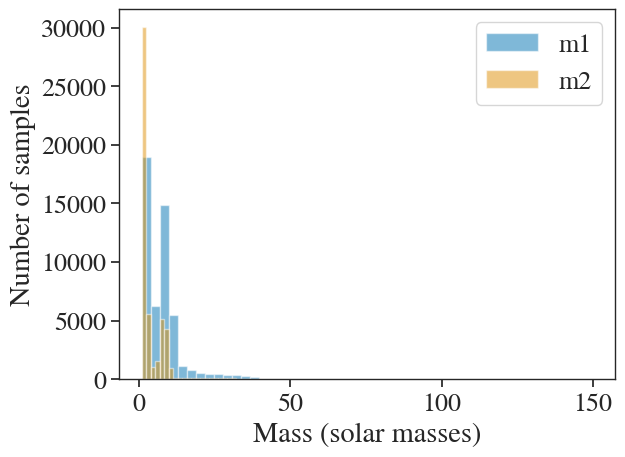

In [12]:
import pylab as plt
plt.hist(mass_samples['mass_1_source'], bins=50, alpha=0.5, label='m1')
plt.hist(mass_samples['mass_2_source'], bins=50, alpha=0.5, label='m2')
plt.xlabel('Mass (solar masses)')
plt.ylabel('Number of samples')
plt.legend()